## Proyecto 2 Aprendizaje De Maquina: Clasificación de la estabilidad de una red eléctrica mediante modelos de aprendizaje automático 
**Base de datos:** Electrical Grid Stability Simulated Data

**Manolo Restrepo Gil - Julián David Osorio londoño**


## Descripción de la base de datos

La base de datos utilizada en este proyecto se denomina **Electrical Grid Stability Simulated Data**. Corresponde a un conjunto de datos generado mediante simulaciones de una red eléctrica compuesta por cuatro nodos.

El dominio del problema corresponde al área de los **sistemas eléctricos de potencia**, específicamente al análisis de estabilidad de una red eléctrica.

La base de datos contiene diferentes parámetros que caracterizan el comportamiento de los cuatro nodos de la red. Entre estos parámetros se encuentran los tiempos de reacción (tau), las potencias nominales (p) y los coeficientes relacionados con la elasticidad (g).

Cada registro representa una configuración simulada de la red eléctrica. Para cada configuración se dispone de las características de los cuatro nodos y de una variable que indica el estado de estabilidad del sistema.

El objetivo del proyecto es utilizar las variables asociadas a la configuración de la red para construir un modelo capaz de clasificar una nueva configuración como:

- **stable:** sistema estable.
- **unstable:** sistema inestable.

La base de datos contiene 10.000 observaciones y 14 variables.

De las 14 columnas:

- 12 corresponden a variables de entrada relacionadas con los nodos.
- 1 corresponde a la variable stab, que representa un indicador numérico de estabilidad.
- 1 corresponde a la variable categórica stabf, que representa la clasificación final de estabilidad.

No existen valores faltantes en la base de datos.

## Dominio del problema

El problema pertenece al dominio de la Ingeniería Electrónica y los sistemas eléctricos de potencia.

En una red eléctrica, diferentes parámetros de los componentes pueden modificar la estabilidad general del sistema. Por esta razón, disponer de herramientas capaces de identificar automáticamente configuraciones potencialmente inestables puede ser útil como mecanismo de apoyo para el análisis y supervisión de sistemas eléctricos.

En este proyecto se plantea el uso de Machine Learning como una herramienta de clasificación. En lugar de calcular directamente la estabilidad mediante métodos matemáticos tradicionales, se busca que un modelo aprenda los patrones existentes en las simulaciones y posteriormente pueda clasificar nuevas configuraciones.

La aplicación potencial de este tipo de modelo está relacionada con:

- Supervisión de sistemas eléctricos.
- Análisis preventivo de estabilidad.
- Sistemas inteligentes de apoyo a la operación.
- Automatización del análisis de redes eléctricas.
- Detección temprana de configuraciones potencialmente inestables.
- Integración de técnicas de Inteligencia Artificial en sistemas eléctricos.

## Utilidad del proyecto

El desarrollo de un modelo de clasificación para estabilidad eléctrica permite explorar cómo las técnicas de Machine Learning pueden utilizarse dentro de aplicaciones de Ingeniería Electrónica.

Una vez entrenado, el modelo puede recibir los parámetros correspondientes a una configuración de una red eléctrica y generar una predicción sobre su estado.

La utilidad principal del proyecto consiste en desarrollar y comparar diferentes algoritmos para determinar qué comportamiento presentan frente al problema de clasificación seleccionado.

## Definición del problema de Machine Learning

El proyecto corresponde a un problema de aprendizaje supervisado, ya que se dispone de un conjunto de variables de entrada y una variable de salida conocida para cada observación.

El objetivo es desarrollar un modelo capaz de determinar si una configuración de la red eléctrica es estable o inestable.

### Variables utilizadas

| Variable | Tipo de variable | Tipo de dato | Descripción | Uso en el modelo |
|:---:|:---:|:---:|---|:---:|
| `tau1` | Continua | Numérica | Tiempo de reacción del nodo 1 | Entrada |
| `tau2` | Continua | Numérica | Tiempo de reacción del nodo 2 | Entrada |
| `tau3` | Continua | Numérica | Tiempo de reacción del nodo 3 | Entrada |
| `tau4` | Continua | Numérica | Tiempo de reacción del nodo 4 | Entrada |
| `p1` | Continua | Numérica | Potencia del nodo productor 1 | Entrada |
| `p2` | Continua | Numérica | Potencia del nodo consumidor 2 | Entrada |
| `p3` | Continua | Numérica | Potencia del nodo consumidor 3 | Entrada |
| `p4` | Continua | Numérica | Potencia del nodo consumidor 4 | Entrada |
| `g1` | Continua | Numérica | Coeficiente de elasticidad del nodo 1 | Entrada |
| `g2` | Continua | Numérica | Coeficiente de elasticidad del nodo 2 | Entrada |
| `g3` | Continua | Numérica | Coeficiente de elasticidad del nodo 3 | Entrada |
| `g4` | Continua | Numérica | Coeficiente de elasticidad del nodo 4 | Entrada |
| `stab` | Continua | Numérica | Indicador numérico asociado a la estabilidad del sistema | **No utilizada** |
| `stabf` | Categórica binaria | Texto | Clasificación final del sistema: `stable` o `unstable` | **Variable de salida** |

### Variable de salida

La variable objetivo será stabf, que posee dos posibles categorías:

- `stable`: sistema estable.
- `unstable`: sistema inestable.

Para entrenar los modelos, estas categorías se convertirán posteriormente a valores numéricos:

- `stable` → 0
- `unstable` → 1

La variable `stab` se excluirá de las variables de entrada debido a que está directamente relacionada con el criterio de estabilidad. Utilizarla como predictor podría generar data leakage* y producir una evaluación artificialmente favorable del modelo.


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import joblib

import warnings
warnings.filterwarnings("ignore")

In [35]:
ruta = "Data_for_UCI_named.csv"

df = pd.read_csv(ruta)

df.head(10)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable
5,6.999209,9.109247,3.784066,4.267788,4.429669,-1.857139,-0.670397,-1.902133,0.261793,0.077930,0.542884,0.469931,-0.017385,stable
6,6.710166,3.765204,6.929314,8.818562,2.397419,-0.614590,-1.208826,-0.574004,0.177890,0.397977,0.402046,0.376630,0.005954,unstable
7,6.953512,1.379125,5.719400,7.870307,3.224495,-0.748998,-1.186517,-1.288980,0.371385,0.633204,0.732741,0.380544,0.016634,unstable
8,4.689852,4.007747,1.478573,3.733787,4.041300,-1.410344,-1.238204,-1.392751,0.269708,0.250364,0.164941,0.482439,-0.038677,stable
9,9.841496,1.413822,9.769856,7.641616,4.727595,-1.991363,-0.857637,-1.878594,0.376356,0.544415,0.792039,0.116263,0.012383,unstable


In [36]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])
print("Dimensiones de la base:", df.shape)

Número de filas: 10000
Número de columnas: 14
Dimensiones de la base: (10000, 14)


In [37]:
# Últimas 5 observaciones
df.tail()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
9995,2.930406,9.487627,2.376523,6.187797,3.343416,-0.658054,-1.449106,-1.236256,0.601709,0.779642,0.813512,0.608385,0.023892,unstable
9996,3.392299,1.274827,2.954947,6.894759,4.349512,-1.663661,-0.952437,-1.733414,0.502079,0.567242,0.285880,0.366120,-0.025803,stable
9997,2.364034,2.842030,8.776391,1.008906,4.299976,-1.380719,-0.943884,-1.975373,0.487838,0.986505,0.149286,0.145984,-0.031810,stable
9998,9.631511,3.994398,2.757071,7.821347,2.514755,-0.966330,-0.649915,-0.898510,0.365246,0.587558,0.889118,0.818391,0.037789,unstable
9999,6.530527,6.781790,4.349695,8.673138,3.492807,-1.390285,-1.532193,-0.570329,0.073056,0.505441,0.378761,0.942631,0.045263,unstable


In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  str    
dtypes: float64(13), str(1)
memory usage: 1.1 MB


In [39]:
df.dtypes

tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf        str
dtype: object

##Estadisticas

In [40]:
df.describe()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


In [41]:
estadisticas = df.describe().T

estadisticas

,count,mean,std,min,25%,50%,75%,max
tau1,10000.0,5.250000,2.742548,0.500793,2.874892,5.250004,7.624690,9.999469
tau2,10000.0,5.250001,2.742549,0.500141,2.875140,5.249981,7.624893,9.999837
tau3,10000.0,5.250004,2.742549,0.500788,2.875522,5.249979,7.624948,9.999450
tau4,10000.0,5.249997,2.742556,0.500473,2.874950,5.249734,7.624838,9.999443
p1,10000.0,3.750000,0.752160,1.582590,3.218300,3.751025,4.282420,5.864418
p2,10000.0,-1.250000,0.433035,-1.999891,-1.624901,-1.249966,-0.874977,-0.500108
p3,10000.0,-1.250000,0.433035,-1.999945,-1.625025,-1.249974,-0.875043,-0.500072
p4,10000.0,-1.250000,0.433035,-1.999926,-1.624960,-1.250007,-0.875065,-0.500025
g1,10000.0,0.525000,0.274256,0.050009,0.287521,0.525009,0.762435,0.999937
g2,10000.0,0.525000,0.274255,0.050053,0.287552,0.525003,0.762490,0.999944


## Descripción de las variables

Las variables de la base de datos pueden dividirse en tres grupos principales:

1. Variables relacionadas con los tiempos de reacción (`tau`).
2. Variables relacionadas con la potencia (`p`).
3. Variables relacionadas con los coeficientes de elasticidad (`g`).

Adicionalmente, la base contiene las variables `stab` y `stabf`, relacionadas con la estabilidad del sistema.

In [42]:
variables_predictoras = [
    "tau1", "tau2", "tau3", "tau4",
    "p1", "p2", "p3", "p4",
    "g1", "g2", "g3", "g4"
]

variable_objetivo = "stabf"

print("Variables predictoras:")
for variable in variables_predictoras:
    print("-", variable)

print("\nVariable objetivo:", variable_objetivo)

Variables predictoras:
- tau1
- tau2
- tau3
- tau4
- p1
- p2
- p3
- p4
- g1
- g2
- g3
- g4

Variable objetivo: stabf


In [43]:
conteo_clases = df["stabf"].value_counts()

conteo_clases

stabf
unstable    6380
stable      3620
Name: count, dtype: int64

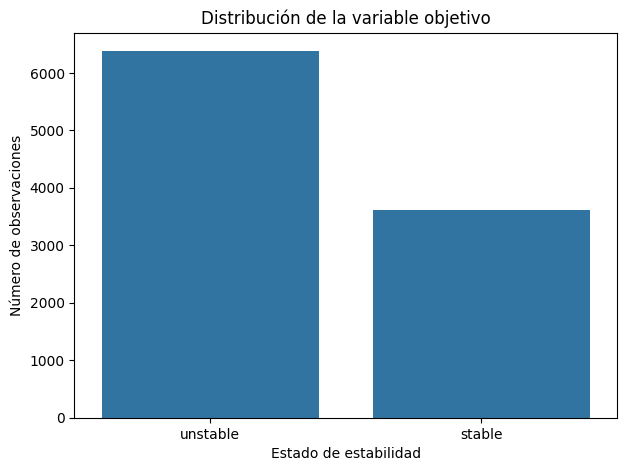

In [44]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="stabf"
)

plt.title("Distribución de la variable objetivo")
plt.xlabel("Estado de estabilidad")
plt.ylabel("Número de observaciones")

plt.show()

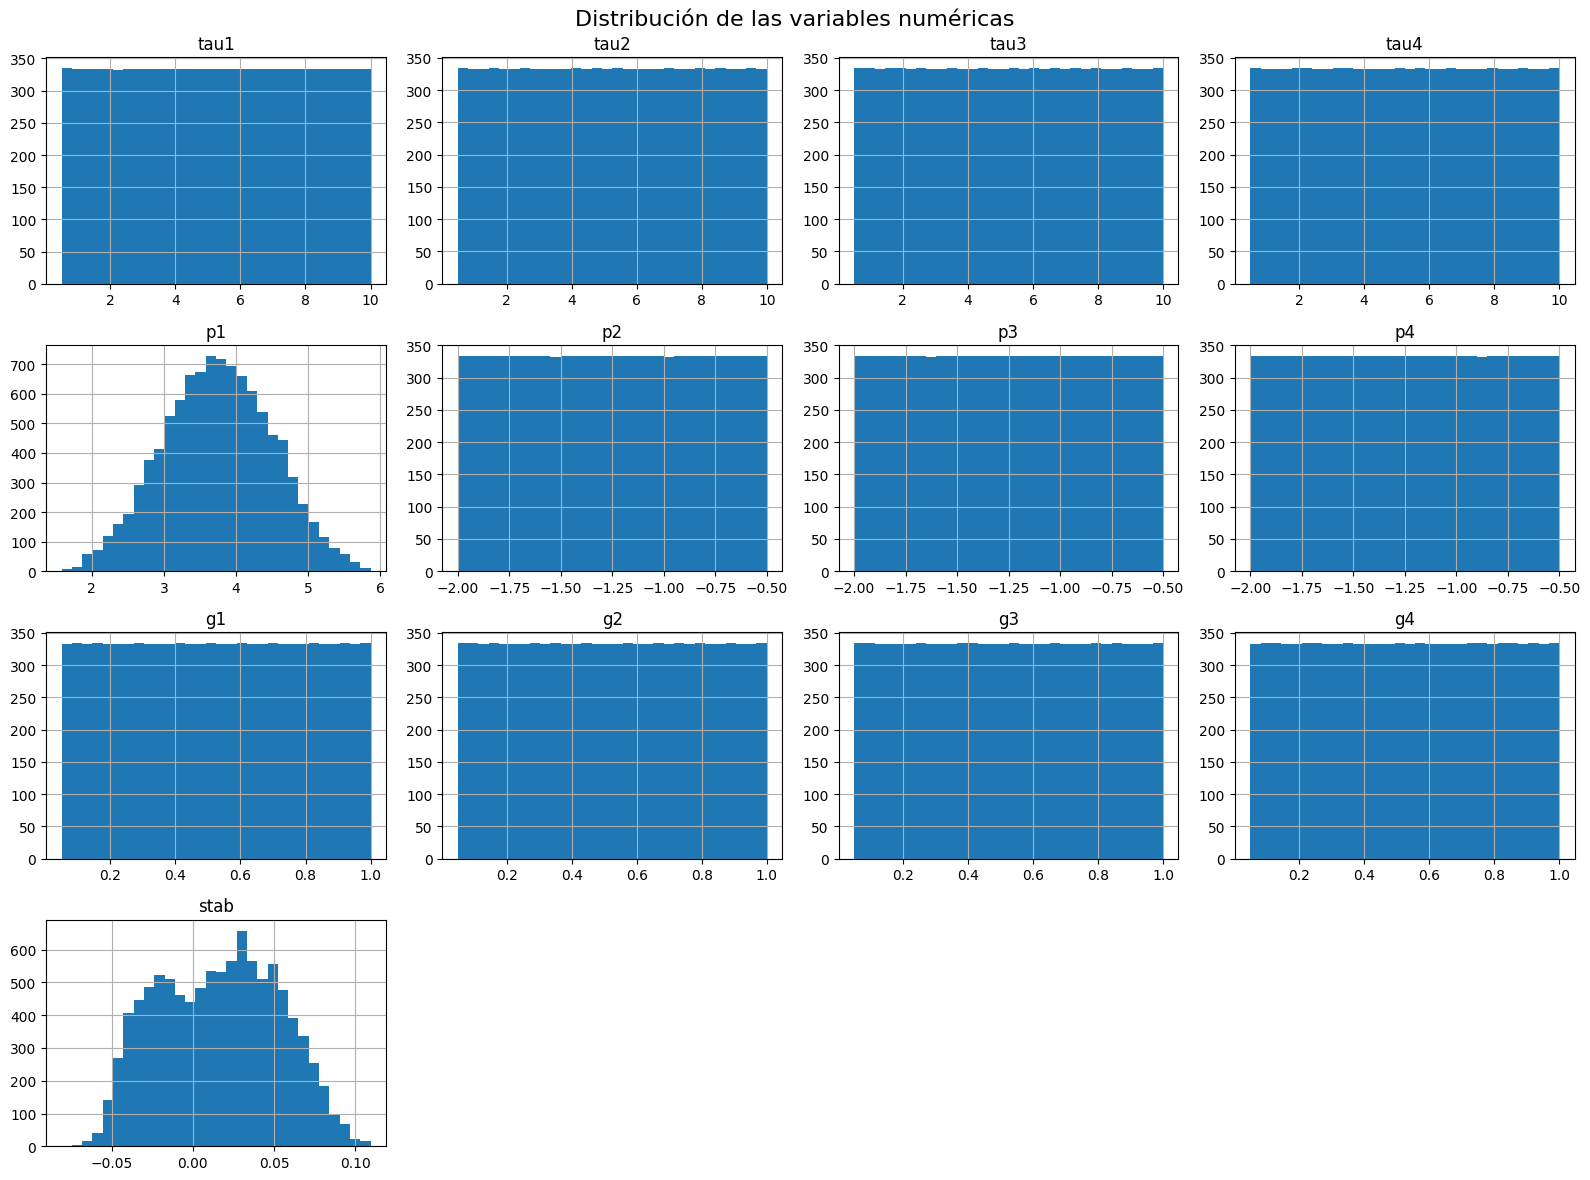

In [45]:
variables_numericas = variables_predictoras + ["stab"]

df[variables_numericas].hist(
    figsize=(16,12),
    bins=30
)

plt.suptitle(
    "Distribución de las variables numéricas",
    fontsize=16
)

plt.tight_layout()
plt.show()

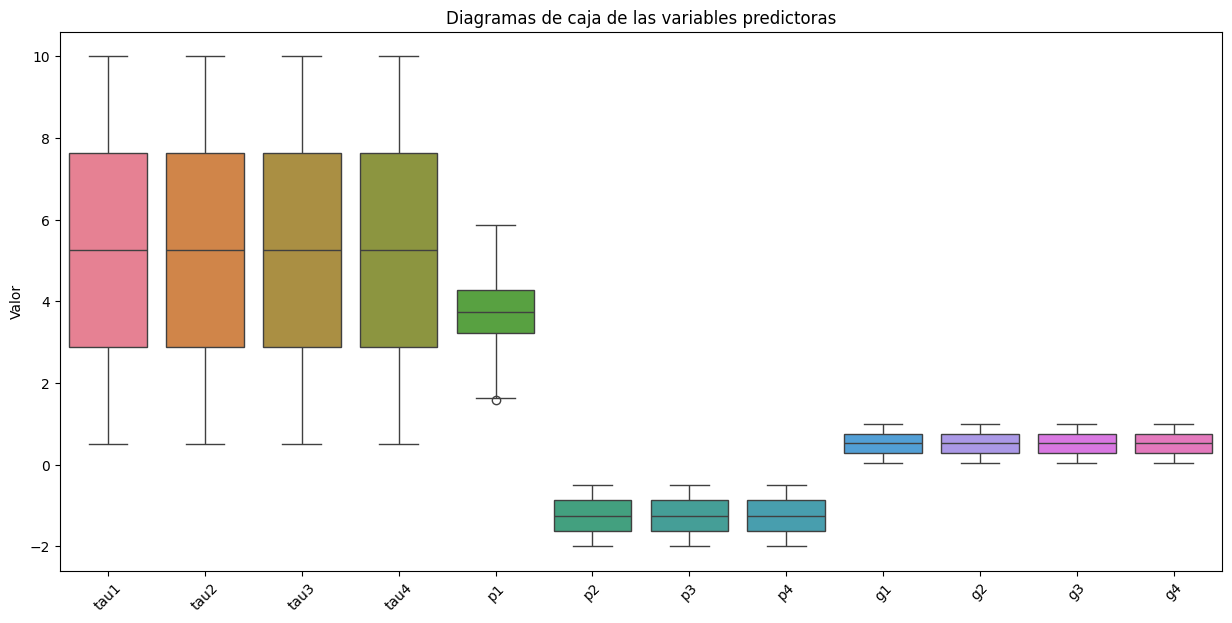

In [46]:
plt.figure(figsize=(15,7))

sns.boxplot(
    data=df[variables_predictoras]
)

plt.title("Diagramas de caja de las variables predictoras")
plt.xticks(rotation=45)
plt.ylabel("Valor")

plt.show()

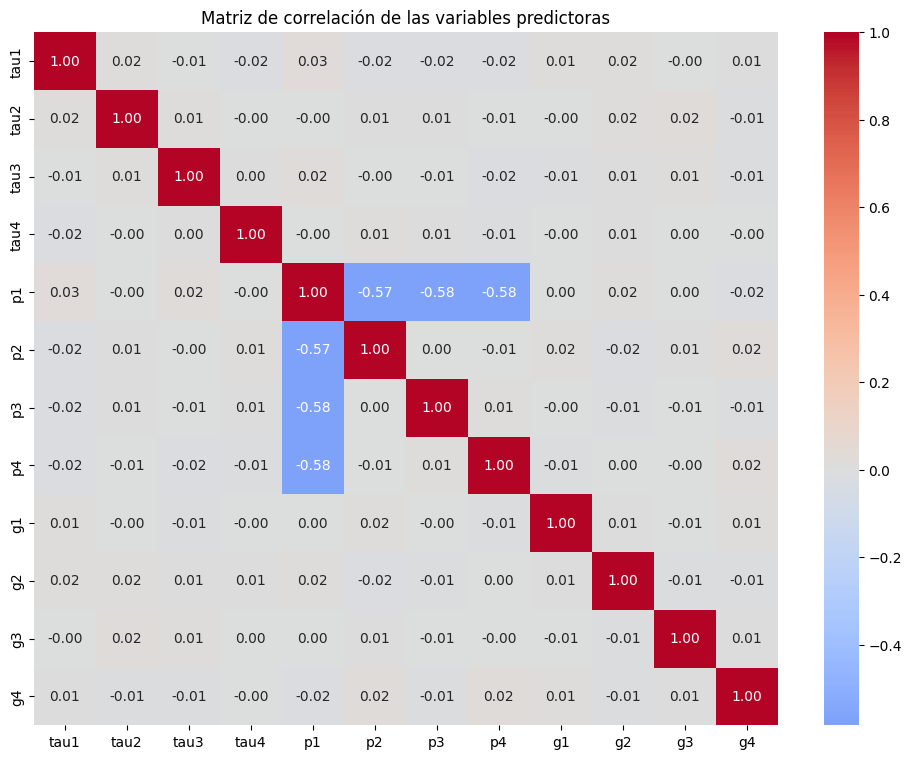

In [47]:
plt.figure(figsize=(12,9))

correlacion = df[variables_predictoras].corr()

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación de las variables predictoras")

plt.show()

In [48]:
# Variables predictoras
X = df[variables_predictoras].copy()

# Variable objetivo
y = df["stabf"].map({
    "stable": 0,
    "unstable": 1
})

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (10000, 12)
Dimensiones de y: (10000,)


In [49]:
print("Variables utilizadas:")
print(X.columns.tolist())

print("\nClases de la variable objetivo:")
print(y.value_counts())

Variables utilizadas:
['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']

Clases de la variable objetivo:
stabf
1    6380
0    3620
Name: count, dtype: int64


## División de los datos

Se dividirá la base de datos en dos subconjuntos:

- **80 % para entrenamiento:** utilizado para ajustar los modelos y realizar la validación cruzada.
- **20 % para prueba:** reservado para realizar una evaluación final sobre datos que no participaron en el entrenamiento.

Se utilizará stratify=y para conservar aproximadamente la misma proporción de clases en los conjuntos de entrenamiento y prueba.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (8000, 12)
Datos de prueba: (2000, 12)


## Validación cruzada de 10 folds

Para evaluar los modelos durante el proceso de entrenamiento se utilizará validación cruzada estratificada con 10 folds.

Se utilizará `StratifiedKFold` debido a que el problema es de clasificación y existe cierto desbalance entre las clases.

Además, se utilizará `GridSearchCV` para probar diferentes combinaciones de hiperparámetros y seleccionar la configuración con el mejor rendimiento promedio durante la validación cruzada.

In [51]:
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

print("Número de folds:", cv.n_splits)

Número de folds: 10


# Modelo 1 — Árbol de decisión

El árbol de decisión es un algoritmo de clasificación que divide los datos mediante reglas basadas en las variables predictoras.

En este proyecto se probarán diferentes valores de:

- `criterion`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

La búsqueda de hiperparámetros se realizará mediante `GridSearchCV` y validación cruzada de 10 folds.

In [52]:
modelo_arbol = DecisionTreeClassifier(
    random_state=42
)

parametros_arbol = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_arbol = GridSearchCV(
    estimator=modelo_arbol,
    param_grid=parametros_arbol,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_arbol.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_arbol.best_params_)

print("\nMejor Accuracy promedio:")
print(grid_arbol.best_score_)

Mejores parámetros:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Mejor Accuracy promedio:
0.858


# Modelo 2 — Bagging con árboles

Bagging (*Bootstrap Aggregating*) es una técnica de ensamble que construye múltiples modelos a partir de diferentes muestras de los datos y combina sus predicciones.

Para este proyecto se utilizarán árboles de decisión como estimadores base.

Se probarán diferentes valores para:

- Número de estimadores.
- Porcentaje de muestras utilizadas.
- Porcentaje de variables utilizadas.

In [53]:
modelo_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    random_state=42,
    n_jobs=-1
)

parametros_bagging = {
    "n_estimators": [50, 100, 200],
    "max_samples": [0.7, 1.0],
    "max_features": [0.7, 1.0]
}

grid_bagging = GridSearchCV(
    estimator=modelo_bagging,
    param_grid=parametros_bagging,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_bagging.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_bagging.best_params_)

print("\nMejor Accuracy promedio:")
print(grid_bagging.best_score_)

Mejores parámetros:
{'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 200}

Mejor Accuracy promedio:
0.91525


# Modelo 3 — Random Forest

Random Forest es un método de ensamble basado en múltiples árboles de decisión.

A diferencia de un árbol individual, Random Forest utiliza diferentes muestras de los datos y diferentes subconjuntos de variables durante la construcción de los árboles.

Se probarán diferentes valores de:

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `max_features`

In [54]:
modelo_rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

parametros_rf = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "max_features": ["sqrt", "log2"]
}

grid_rf = GridSearchCV(
    estimator=modelo_rf,
    param_grid=parametros_rf,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_rf.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_rf.best_params_)

print("\nMejor Accuracy promedio:")
print(grid_rf.best_score_)

Mejores parámetros:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}

Mejor Accuracy promedio:
0.920625


# Modelo 4 — AdaBoost

AdaBoost es un método de ensamble que combina múltiples modelos débiles de forma secuencial. Durante el entrenamiento, el algoritmo asigna mayor importancia a las observaciones que han sido clasificadas incorrectamente por los modelos anteriores.

Se probarán diferentes valores de:

- `n_estimators`
- `learning_rate`

In [55]:
modelo_ada = AdaBoostClassifier(
    random_state=42
)

parametros_ada = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5, 1.0]
}

grid_ada = GridSearchCV(
    estimator=modelo_ada,
    param_grid=parametros_ada,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_ada.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_ada.best_params_)

print("\nMejor Accuracy promedio:")
print(grid_ada.best_score_)

Mejores parámetros:
{'learning_rate': 0.5, 'n_estimators': 200}

Mejor Accuracy promedio:
0.843125


# Modelo 5 — XGBoost

XGBoost es un algoritmo de ensamble basado en árboles que utiliza el principio de Gradient Boosting.

El algoritmo construye árboles de manera secuencial, utilizando los errores de los modelos anteriores para mejorar progresivamente el modelo.

Se evaluarán diferentes combinaciones de:

- `n_estimators`
- `max_depth`
- `learning_rate`
- `subsample`

In [56]:
modelo_xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

parametros_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=modelo_xgb,
    param_grid=parametros_xgb,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    return_train_score=True
)

grid_xgb.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_xgb.best_params_)

print("\nMejor Accuracy promedio:")
print(grid_xgb.best_score_)

Mejores parámetros:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}

Mejor Accuracy promedio:
0.9469999999999998


# Comparacion de los modelos

In [57]:
modelos = {
    "Árbol de decisión": grid_arbol,
    "Bagging": grid_bagging,
    "Random Forest": grid_rf,
    "AdaBoost": grid_ada,
    "XGBoost": grid_xgb
}

resultados = []

for nombre, modelo in modelos.items():

    predicciones = modelo.predict(X_test)

    resultados.append({
        "Modelo": nombre,
        "Accuracy_CV": modelo.best_score_,
        "Accuracy_Test": accuracy_score(y_test, predicciones),
        "Precision": precision_score(y_test, predicciones),
        "Recall": recall_score(y_test, predicciones),
        "F1": f1_score(y_test, predicciones)
    })

resultados_df = pd.DataFrame(resultados)

resultados_df

,Modelo,Accuracy_CV,Accuracy_Test,Precision,Recall,F1
0,Árbol de decisión,0.858000,0.8585,0.893735,0.883229,0.888451
1,Bagging,0.915250,0.9155,0.926754,0.942006,0.934318
2,Random Forest,0.920625,0.9245,0.924528,0.960031,0.941945
3,AdaBoost,0.843125,0.8645,0.868672,0.927900,0.897310
4,XGBoost,0.947000,0.9515,0.953811,0.971003,0.962330


In [58]:
resultados_df.sort_values(
    by="Accuracy_Test",
    ascending=False
).reset_index(drop=True)

,Modelo,Accuracy_CV,Accuracy_Test,Precision,Recall,F1
0,XGBoost,0.947000,0.9515,0.953811,0.971003,0.962330
1,Random Forest,0.920625,0.9245,0.924528,0.960031,0.941945
2,Bagging,0.915250,0.9155,0.926754,0.942006,0.934318
3,AdaBoost,0.843125,0.8645,0.868672,0.927900,0.897310
4,Árbol de decisión,0.858000,0.8585,0.893735,0.883229,0.888451


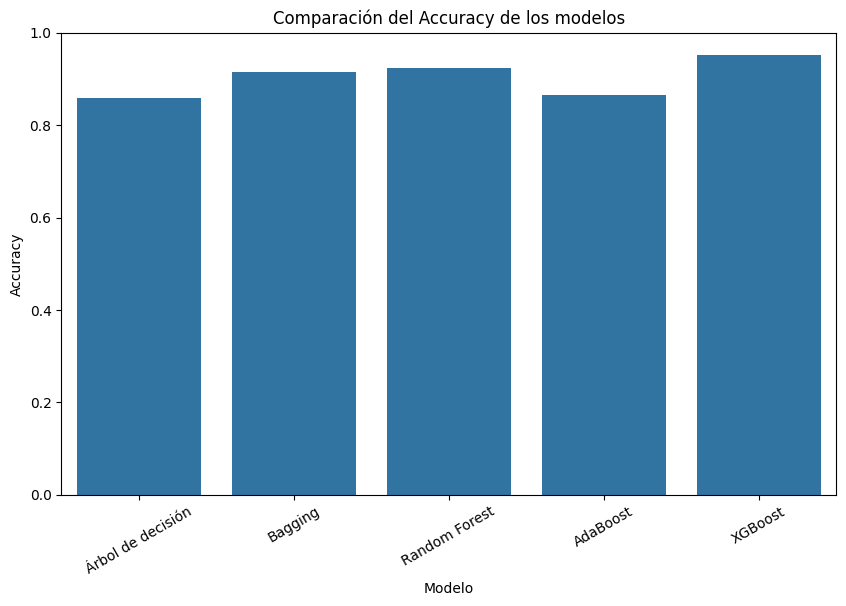

In [59]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=resultados_df,
    x="Modelo",
    y="Accuracy_Test"
)

plt.title("Comparación del Accuracy de los modelos")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")

plt.xticks(rotation=30)

plt.ylim(0, 1)

plt.show()

# Selección del modelo

A partir de los resultados obtenidos, se comparan los cinco algoritmos utilizando las métricas calculadas sobre el conjunto de prueba.

El modelo seleccionado será aquel que presente el comportamiento más adecuado de acuerdo con las métricas utilizadas en este proyecto.

Además del Accuracy, se tendrán en cuenta Precision, Recall y F1-score, debido a que el conjunto de datos presenta una diferencia en la cantidad de observaciones pertenecientes a las dos clases.

La selección se realizará a partir de los resultados obtenidos experimentalmente y no únicamente a partir de las características teóricas de los algoritmos.

In [60]:
indice_mejor = resultados_df["F1"].idxmax()

nombre_mejor = resultados_df.loc[
    indice_mejor, "Modelo"
]

print("Modelo seleccionado:", nombre_mejor)

Modelo seleccionado: XGBoost


In [61]:
mejor_grid = modelos[nombre_mejor]

mejor_modelo = mejor_grid.best_estimator_

print("Modelo:")
print(mejor_modelo)

print("\nHiperparámetros:")
print(mejor_grid.best_params_)

Modelo:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

Hiperparámetros:
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}


# Matriz De Confusion del modelo

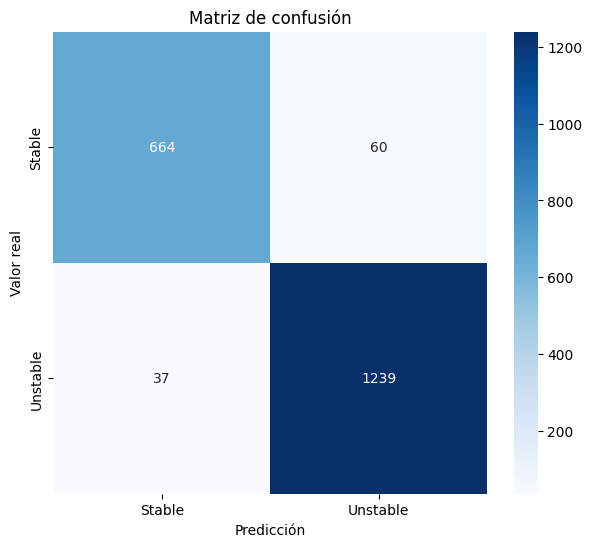

In [62]:
y_pred = mejor_modelo.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stable", "Unstable"],
    yticklabels=["Stable", "Unstable"]
)

plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.show()

In [63]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Stable", "Unstable"]
    )
)

              precision    recall  f1-score   support

      Stable       0.95      0.92      0.93       724
    Unstable       0.95      0.97      0.96      1276

    accuracy                           0.95      2000
   macro avg       0.95      0.94      0.95      2000
weighted avg       0.95      0.95      0.95      2000



# Importancia de las variables

Los modelos basados en árboles permiten estimar la importancia relativa de las variables utilizadas durante el proceso de clasificación.

Este análisis permite identificar cuáles de los parámetros de la red eléctrica contribuyen en mayor medida a las decisiones realizadas por el modelo seleccionado.

La importancia de variables debe interpretarse como una medida asociada al modelo y no necesariamente como una relación causal física.

In [64]:
if hasattr(mejor_modelo, "feature_importances_"):

    importancia = pd.DataFrame({
        "Variable": X.columns,
        "Importancia": mejor_modelo.feature_importances_
    })

    importancia = importancia.sort_values(
        by="Importancia",
        ascending=False
    )

    print(importancia)

   Variable  Importancia
3      tau4     0.123504
0      tau1     0.122924
2      tau3     0.122845
1      tau2     0.122634
10       g3     0.113493
9        g2     0.104672
8        g1     0.104120
11       g4     0.103601
4        p1     0.021854
5        p2     0.020917
7        p4     0.020107
6        p3     0.019328


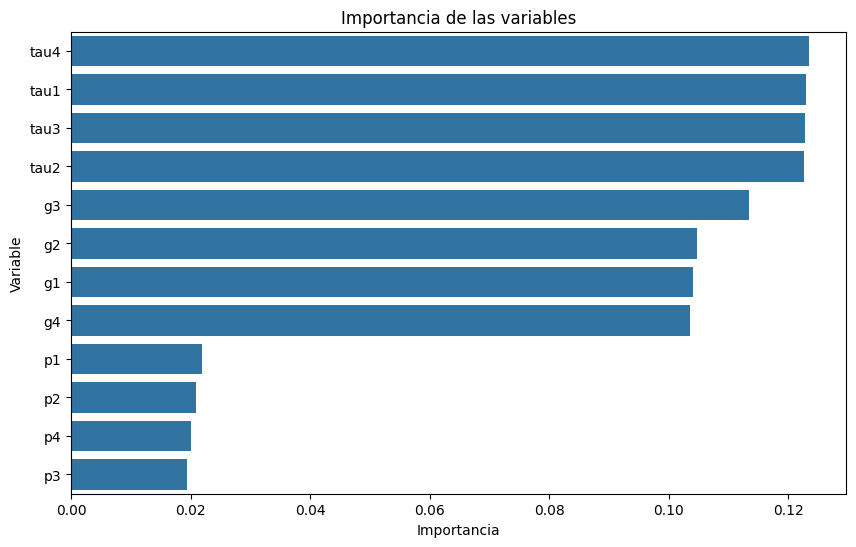

In [65]:
if hasattr(mejor_modelo, "feature_importances_"):

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=importancia,
        x="Importancia",
        y="Variable"
    )

    plt.title("Importancia de las variables")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")

    plt.show()

# Guardado Del Modelo

In [66]:
nombre_archivo = "mejor_modelo_estabilidad_electrica.joblib"

joblib.dump(
    mejor_modelo,
    nombre_archivo
)

print(f"Modelo guardado como: {nombre_archivo}")

Modelo guardado como: mejor_modelo_estabilidad_electrica.joblib


In [67]:
modelo_cargado = joblib.load(
    "mejor_modelo_estabilidad_electrica.joblib"
)

print("Modelo cargado correctamente.")
print(modelo_cargado)

Modelo cargado correctamente.
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)


In [68]:
predicciones_cargado = modelo_cargado.predict(X_test)

accuracy_cargado = accuracy_score(
    y_test,
    predicciones_cargado
)

print("Accuracy del modelo cargado:", accuracy_cargado)

Accuracy del modelo cargado: 0.9515
